# ascal — zero-shot calibration of an all-sky camera from one image

This notebook walks through the calibration of a fisheye all-sky camera from a **single night frame**,
with no prior calibration, no sky mask and no manual star identification. You only need:

* the image (any format OpenCV reads; JPEG from a Raspberry Pi camera here),
* the site (latitude, longitude),
* the time of the exposure (from EXIF, from the file name, or typed in).

The pipeline: DAOStarFinder detections → sky-disc detection → a cascade of hypotheses (sky disc, image
parity, radial prior, detection kernel), each with a blind search of the image rotation, zenith offset and
focal scale against the bright stars of the Hipparcos catalogue → progressive association and robust
least-squares fit of the camera model (Kannala–Brandt radial function + rigid 3-D rotation of the optical
axis + image rotation + optical centre; optional Brown–Conrady decentering). The cascade stops at the first
hypothesis that passes the quality gate, within a time budget (40 s by default).

To try your own image: change `IMAGE`, `SITE` and, if needed, `TZ` below.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))      # run from notebooks/ inside the repository; not needed after `pip install .`

import numpy as np
from IPython.display import Image, display

import ascal
from ascal import Site, calibrate, evaluate, load_frame
from ascal import plots

IMAGES = Path.cwd().parent / "examples" / "images"
IMAGE = IMAGES / "2026_08_09_03_00_46.jpg"      # <- your image here
SITE = Site(lat=43.259147, lon=-6.60345, elev=650)   # <- your site here (degrees north / east)
TZ = "Europe/Madrid"                            # time zone of the timestamp in the file name (EXIF DateTimeOriginal is used when present)
print("ascal", ascal.__version__)

ascal 1.0.0


## 1. Load the frame and detect stars

`load_frame` reads the image, works out the mid-exposure instant (UTC), finds the illuminated sky disc
and runs DAOStarFinder (2-D median background in 128 px boxes, 4σ threshold, sharpness and roundness
cuts) inside the disc.

2026_08_09_03_00_46.jpg: 4056x3040 px, mid-exposure 2026-08-09 01:00:56 UTC, exposure 20.0 s
4605 detections; sky disc centre (2004, 1390), radius 1438 px


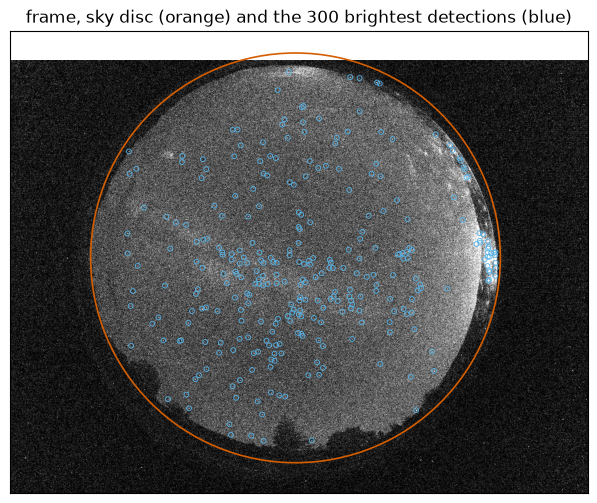

In [2]:
frame = load_frame(IMAGE, tz=TZ, keep_image=True)
print(f"{frame.path.name}: {frame.width}x{frame.height} px, mid-exposure {frame.utc} UTC, exposure {frame.exposure_s} s")
print(f"{len(frame.detections)} detections; sky disc centre ({frame.disc[0]:.0f}, {frame.disc[1]:.0f}), radius {frame.disc[2]:.0f} px")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
small = frame.gray[::4, ::4]
ax.imshow(small, cmap="gray", vmin=np.percentile(small, 5), vmax=np.percentile(small, 99.7), extent=(0, frame.width, frame.height, 0))
ax.add_patch(plt.Circle(frame.disc[:2], frame.disc[2], fill=False, color="#D55E00", lw=1.2))
d = frame.detections
top = d.order[:300]
ax.scatter(d.x[top], d.y[top], s=12, facecolors="none", edgecolors="#56B4E9", linewidths=0.6)
ax.set_title("frame, sky disc (orange) and the 300 brightest detections (blue)")
ax.set_xticks([]); ax.set_yticks([]); plt.show()

## 2. Calibrate

`calibrate` runs the cascade. For each hypothesis the log lists the best poses of the blind search for both
parities (number of bright catalogue stars that land on a detection, focal length, image rotation ψ) and the
refinement of the best ones, with the quality gate: matched pairs against the number required (15 % of the
stars expected down to the frame's limiting magnitude), the margin of the best pose over its rivals, and the
median residual. On this frame the first hypothesis (sky disc as detected, direct image, equisolid-like prior)
is accepted.

In [3]:
result = calibrate([frame], SITE, decentering=False, verbose=True)
model = result.model
summary = result.summary()
print()
print(model)
print(f"total tilt {model.total_tilt:.2f}°, zenith at pixel ({model.zenith_pixel[0]:.0f}, {model.zenith_pixel[1]:.0f}), "
      f"horizon radius {model.horizon_radius:.0f} px, {60/float(model.plate_scale(0)):.2f} arcmin/px on the axis, "
      f"{60/float(model.plate_scale(90)):.2f} arcmin/px at the horizon")
print(f"{summary['n_pairs']} star–detection pairs, median residual {summary['median_px']:.2f} px, "
      f"{100*summary['within_1px']:.0f}% within 1 px, {summary['elapsed_s']} s in total")
acc = result.info["cascade"]["accepted"]
print("accepted hypothesis:", {k: acc[k] for k in ("disc", "detection", "parity", "first_prior", "margin")})

  [sky_disc] poses: direct n=190 f=1008 psi=161, mirror n=31 f=640 psi=10, direct n=29 f=642 psi=161, mirror n=28 f=643 psi=150


    refine direct prior [-0.03, 0.0]: 528 pairs (need 141 of 945 expected to m<=5.3; pose margin x6.1), median 0.53 px -> ACCEPT



CameraModel(cx=1948.57, cy=1467.81, f=1005.53 px/rad, psi=161.0553°, tilt=(-1.8244, -3.2786)°, k=[-0.0208, -0.00525])
total tilt 3.75°, zenith at pixel (1884, 1456), horizon radius 1448 px, 3.42 arcmin/px on the axis, 4.98 arcmin/px at the horizon
528 star–detection pairs, median residual 0.53 px, 87% within 1 px, 2.2 s in total
accepted hypothesis: {'disc': 'sky_disc', 'detection': 0, 'parity': 'direct', 'first_prior': [-0.03, 0.0], 'margin': 6.13}


## 3. Look at the result

The summary panel, written by the command line with every calibration (`panel.png`): (a) the frame as
recorded; (b) the matched stars with the altitude circles at 0° (dashed), 30° and 60°, the north–south and
east–west lines and the constellation figures, all drawn with the fitted model; (c) altitude in the camera
frame against distance to the optical centre, for the model, an equidistant projection with the same focal
length and the matched stars; (d) residual against altitude, with the median per 10° bin.

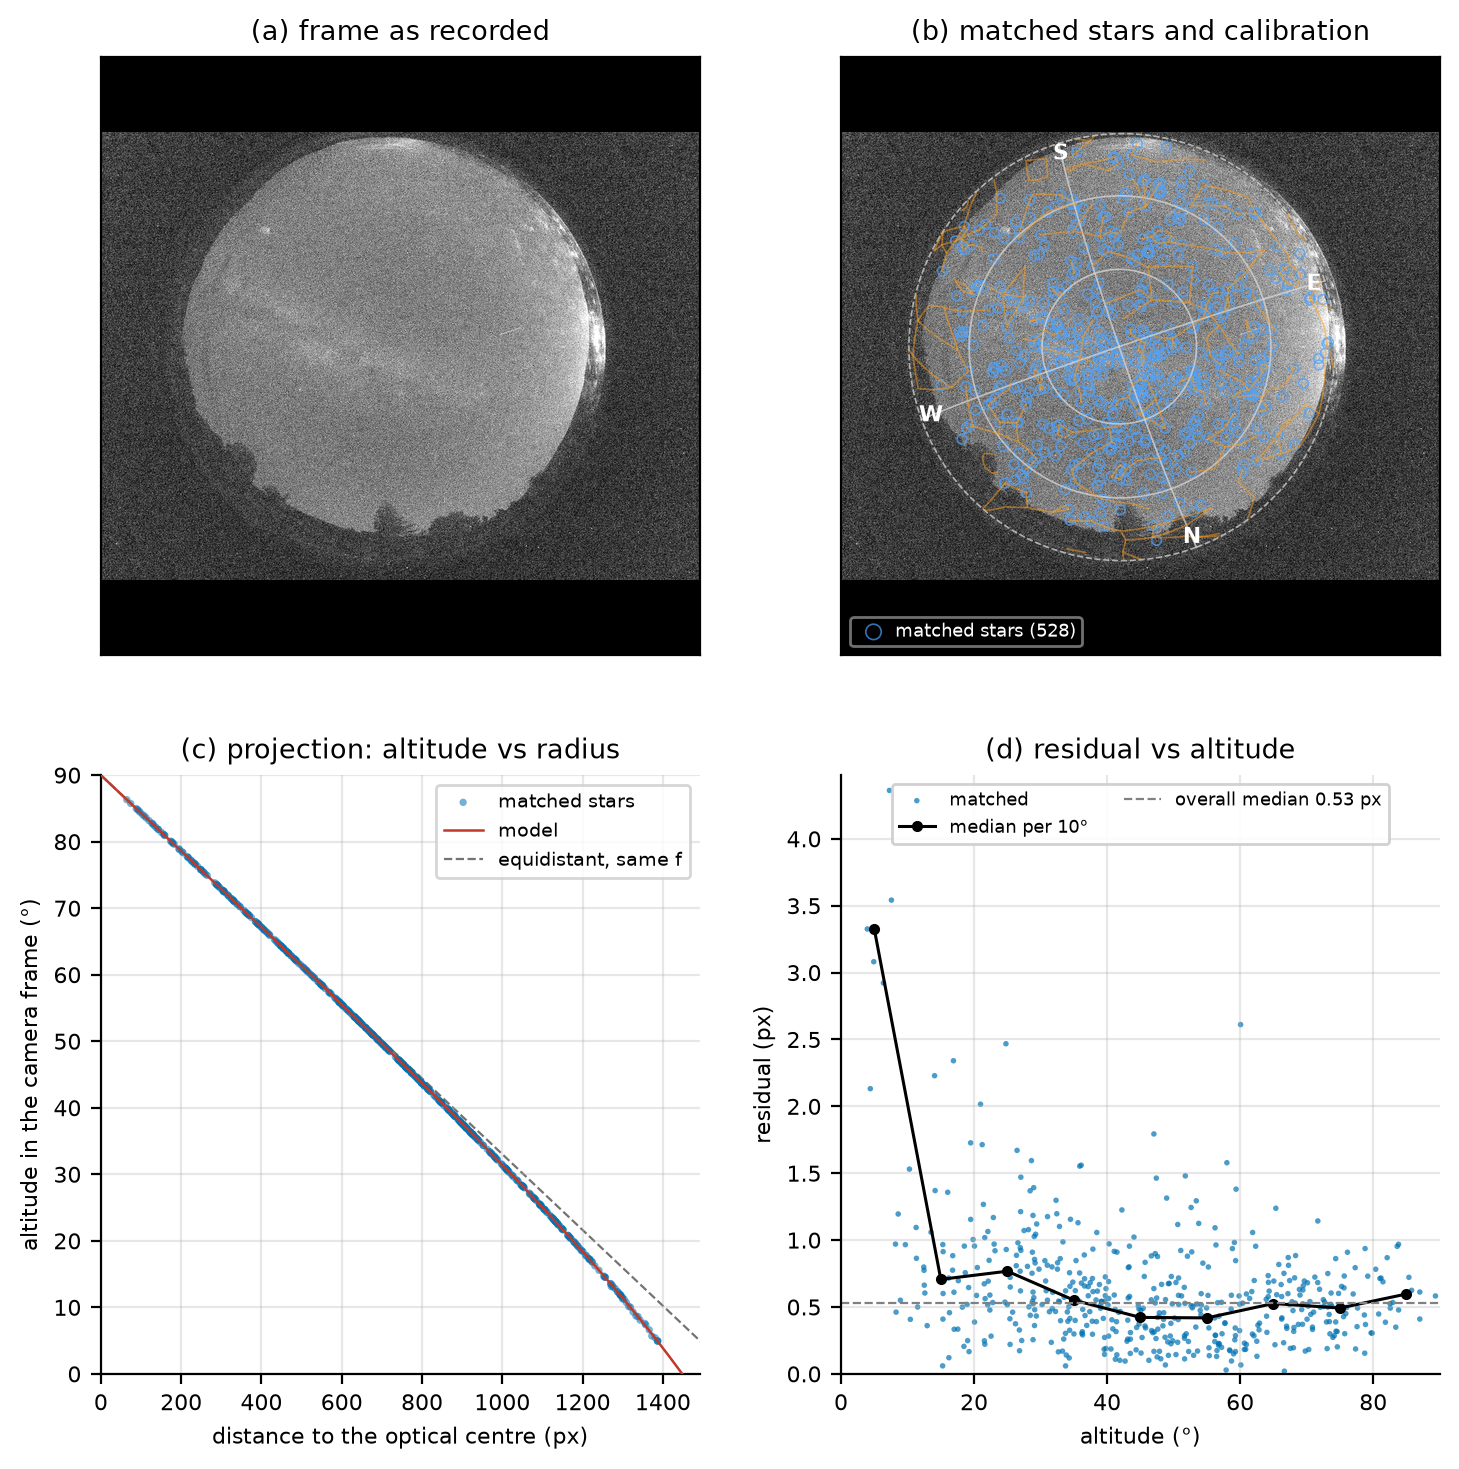

In [4]:
display(Image(plots.calibration_panel(frame, result, SITE)))

Catalogue stars projected with the fitted model over the frame, with the altitude circles (0°, 30°, 60°),
the cardinal meridians, the zenith (star) and the optical centre (+). The camera is tilted, so the
zenith does not coincide with the optical centre.

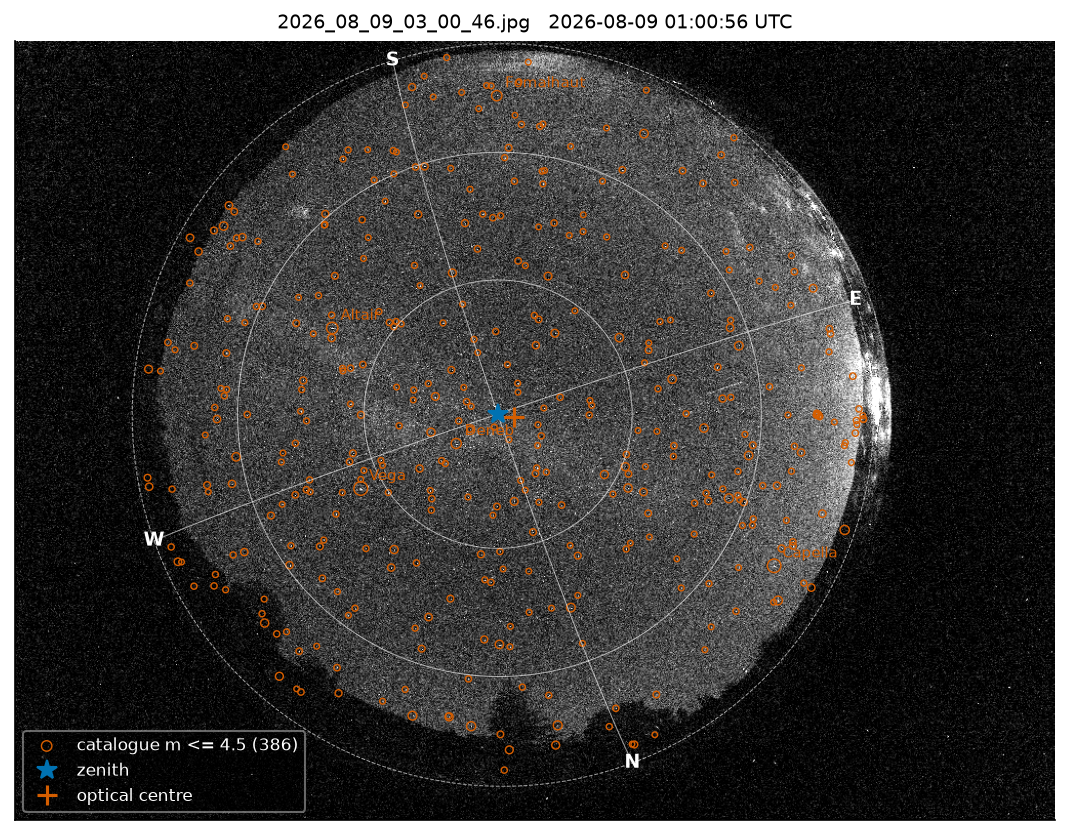

In [5]:
display(Image(plots.overlay(frame, model, SITE, max_mag=4.5)))

Cut-outs around bright stars at low and high altitude: detections (circles) and predicted positions (+).

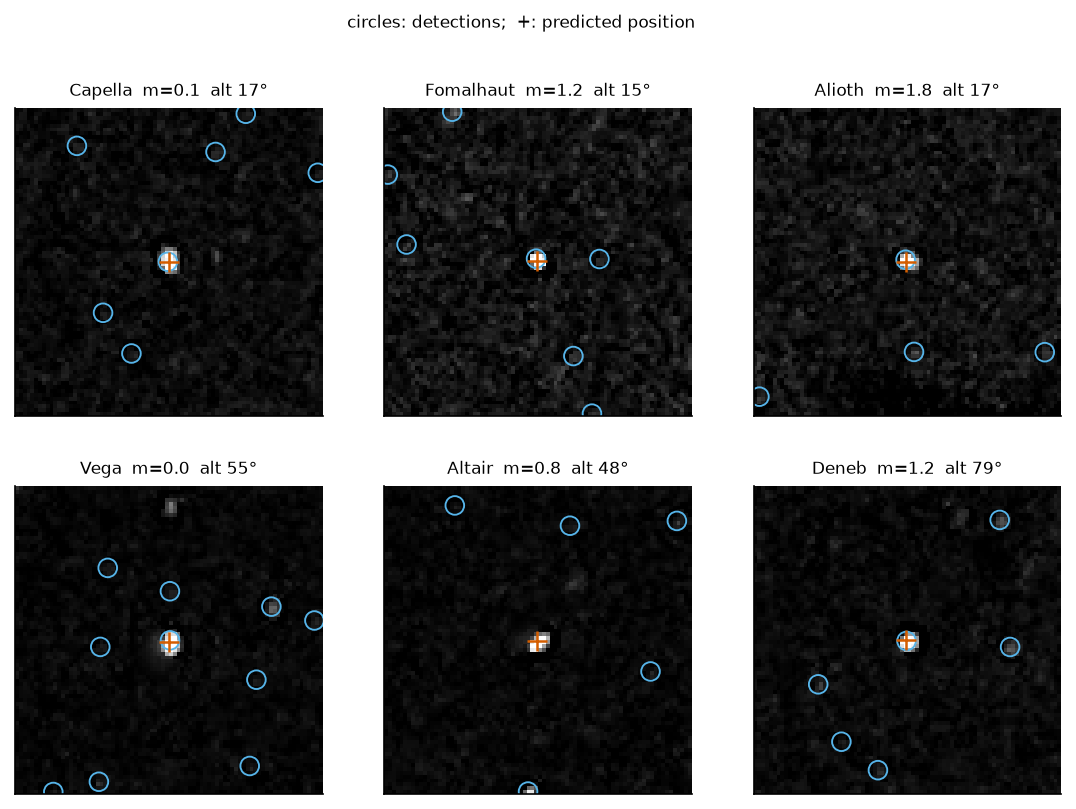

In [6]:
display(Image(plots.cutouts(frame, model, SITE)))

Residuals of the retained pairs against altitude, as vectors on the sensor, and as a histogram.
Sub-pixel agreement over most of the sky is expected; the lowest band (below 10°) is limited by the
detections (extinction, small plate scale, the edge of the disc), not by the model.

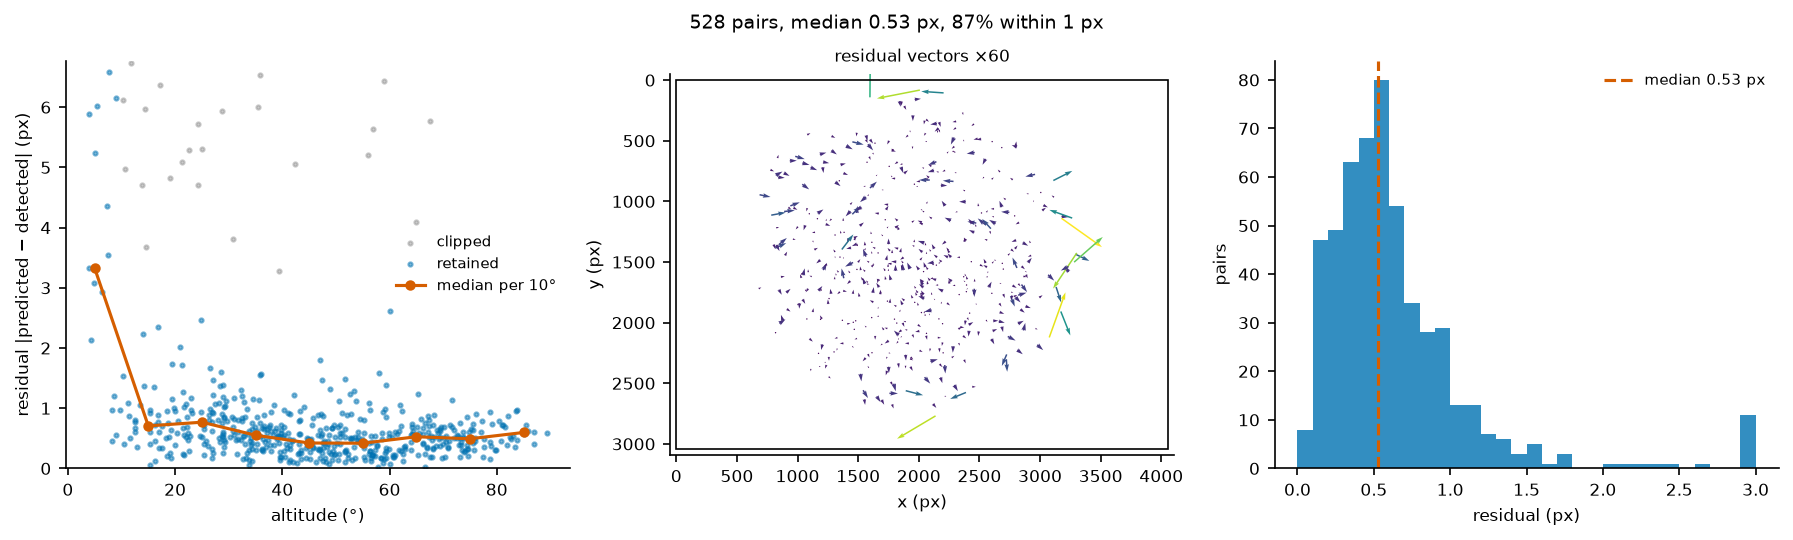

altitude   3-10°:   17 pairs, median 3.33 px, p90 6.33 px, 24% within 1 px
altitude  10-20°:   40 pairs, median 0.71 px, p90 1.39 px, 75% within 1 px
altitude  20-30°:   71 pairs, median 0.77 px, p90 1.37 px, 73% within 1 px
altitude  30-50°:  176 pairs, median 0.49 px, p90 0.92 px, 92% within 1 px
altitude  50-70°:  149 pairs, median 0.48 px, p90 0.93 px, 93% within 1 px
altitude  70-90°:   75 pairs, median 0.50 px, p90 0.79 px, 99% within 1 px
altitude    all°:  528 pairs, median 0.53 px, p90 1.12 px, 87% within 1 px


In [7]:
display(Image(plots.residual_plots(result)))
for b in summary["bands"]:
    if b["n"]:
        print(f"altitude {b['band']:>6}°: {b['n']:4d} pairs, median {b['median']:.2f} px, p90 {b['p90']:.2f} px, {100*b['within_1px']:.0f}% within 1 px")

The radial function compared with the ideal fisheye projections. With `k3 = -0.021` this lens lies
between the equidistant and the equisolid-angle projections; the fitted focal length of ~1005 px/rad
on 1.55 µm pixels is 1.558 mm, against the 1.55 mm of the manufacturer.

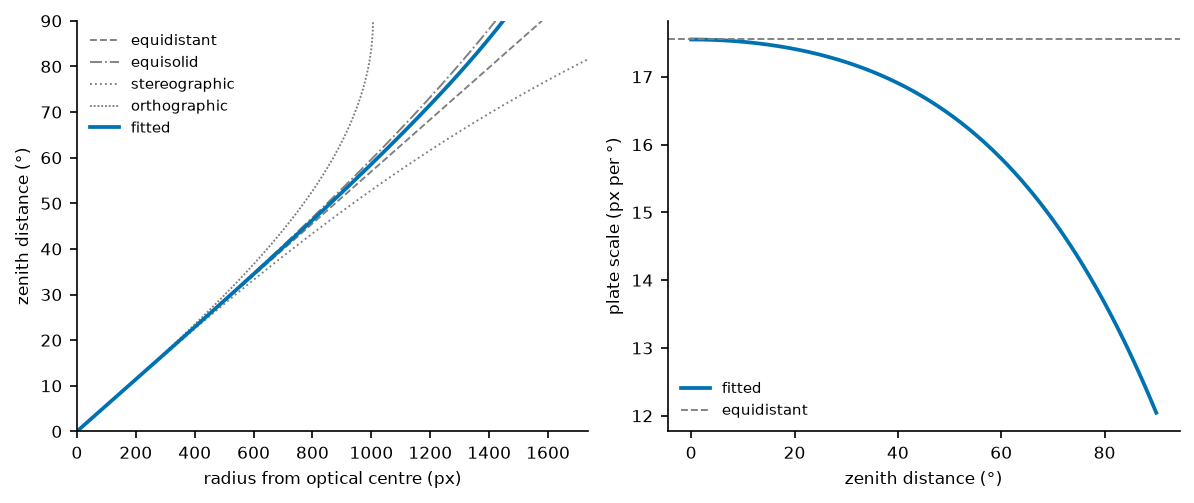

f = 1005.5 px/rad = 1.559 mm for 1.55 µm pixels;  k3 = -0.0208 (0 equidistant, -0.042 equisolid), k5 = -0.0052


In [8]:
display(Image(plots.radial_plot(model)))
print(f"f = {model.f:.1f} px/rad = {model.f * 1.55e-3:.3f} mm for 1.55 µm pixels;  k3 = {model.k[0]:.4f} (0 equidistant, -0.042 equisolid), k5 = {model.k[1]:.4f}")

## 4. Does the calibration transfer to other nights?

The two other frames in `examples/images` come from different nights (one with the Moon up). We
associate their detections with the catalogue using the model fitted above, with **no refitting**,
and look at the residuals.

In [9]:
others = [p for p in sorted(IMAGES.glob("*.jpg")) if p != IMAGE]
for p in others:
    fr = load_frame(p, tz=TZ)
    pairs = evaluate(model, [fr], SITE, max_mag=5.5, radius=10.0)
    d = pairs.residuals(model)
    bright = pairs.mag <= 4.0
    print(f"{p.name}: {len(pairs)} associations, median {np.median(d):.2f} px, {100*np.mean(d < 1):.0f}% within 1 px; "
          f"stars brighter than mag 4: {np.median(d[bright]):.2f} px, {100*np.mean(d[bright] < 1):.0f}% within 1 px")

2026_07_08_01_01_06.jpg: 493 associations, median 0.84 px, 68% within 1 px; stars brighter than mag 4: 0.76 px, 80% within 1 px


2026_07_28_01_00_56.jpg: 202 associations, median 0.69 px, 82% within 1 px; stars brighter than mag 4: 0.62 px, 93% within 1 px


## 5. Mirrored images and options

Some cameras, and FITS files (origin at the bottom), store the sky mirrored. The cascade tries both parities;
a mirrored solution is stored with `"mirror": true`, so the model always maps to the pixels of the file as
given. Here a left–right flipped copy of the frame is calibrated. The options of the command line are
available in Python through `ascal.config.options` (here the parity is left on `auto` and the time budget set
to 30 s).

In [10]:
import dataclasses
flipped = dataclasses.replace(frame, gray=frame.gray[:, ::-1].copy(),
                              detections=dataclasses.replace(frame.detections, x=frame.width - 1 - frame.detections.x),
                              disc=(frame.width - 1 - frame.disc[0], frame.disc[1], frame.disc[2]), info=dict(frame.info))
with ascal.config.options(max_time=30, parity="auto"):
    r_flip = calibrate([flipped], SITE, verbose=False)
print(f"mirror = {r_flip.model.mirror}; {r_flip.summary()['n_pairs']} pairs, median {r_flip.summary()['median_px']:.2f} px")
print(f"same camera: f {r_flip.model.f:.1f} vs {model.f:.1f} px/rad, tilt {r_flip.model.total_tilt:.2f}° vs {model.total_tilt:.2f}°")

mirror = True; 528 pairs, median 0.53 px
same camera: f 1005.5 vs 1005.5 px/rad, tilt 3.75° vs 3.75°


## 6. Save and use the calibration

The model is stored as a small JSON file. `project` converts sky directions to pixels and `unproject`
pixels to sky directions; `solid_angle` gives the steradians covered by each pixel (useful to weight
cloud fraction or sky brightness over the sky).

In [11]:
out = Path.cwd() / "calibration_demo.json"
model.save(out)
print(json.dumps({k: v for k, v in model.to_dict().items() if k != "meta"}, indent=1))

x, y = model.project(np.array([45.0, 10.0]), np.array([0.0, 270.0]))
print("alt 45° az 0° (north) -> pixel", np.round([x[0], y[0]], 1), ";  alt 10° az 270° (west) -> pixel", np.round([x[1], y[1]], 1))
alt, az = model.unproject(np.array([model.width / 2]), np.array([model.height / 2]))
print(f"centre of the sensor -> alt {alt[0]:.2f}°, az {az[0]:.2f}°")
print(f"solid angle per pixel: {model.solid_angle(model.cx, model.cy)*1e6:.2f} µsr on the axis, "
      f"{model.solid_angle(model.cx + 0.95*model.horizon_radius, model.cy)*1e6:.2f} µsr near the horizon")

{
 "model": "kannala-brandt + rigid rotation",
 "cx": 1948.566237543125,
 "cy": 1467.80585573469,
 "f": 1005.5286109657987,
 "psi": 161.0553091467894,
 "tau_x": -1.8243637662124148,
 "tau_y": -3.278646050637831,
 "k": [
  -0.02080255686716448,
  -0.005246332630551902
 ],
 "p": null,
 "width": 4056,
 "height": 3040,
 "mirror": false,
 "derived": {
  "focal_length_px_per_deg": 17.549784984358347,
  "total_tilt_deg": 3.75155823694533,
  "zenith_pixel": [
   1883.7674459339814,
   1456.181663405014
  ],
  "horizon_radius_px": 1447.9600077376053,
  "plate_scale_axis_arcmin_per_px": 3.41884530514057,
  "plate_scale_horizon_arcmin_per_px": 4.9814514506759275
 }
}
alt 45° az 0° (north) -> pixel [2148.2 2189.9] ;  alt 10° az 270° (west) -> pixel [ 656.8 1903.2]
centre of the sensor -> alt 81.01°, az 47.20°
solid angle per pixel: 0.99 µsr on the axis, 0.97 µsr near the horizon


## Command line and web demo

The same pipeline is available from the shell and from a drag-and-drop web page:

```bash
ascal calibrate examples/images/2026_08_09_03_00_46.jpg --lat 43.259147 --lon -6.60345 --elev 650 --tz Europe/Madrid --out calib.json
# -> report in 2026_08_09_03_00_46_ascal/: calibration.json, summary.json, pairs.csv, panel.png and the other figures
ascal check calib.json examples/images/2026_07_08_01_01_06.jpg --lat 43.259147 --lon -6.60345 --tz Europe/Madrid
ascal web          # then open http://127.0.0.1:8000
```